In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [4]:
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,48879,4.889500e+04,48874,48895,48895,48895.000000,48895.000000,48895,48895.000000,48895.000000,48895.000000,38843,38843.000000,48895.000000,48895.000000
unique,NaN,47905,NaN,11452,5,221,NaN,NaN,3,NaN,NaN,NaN,1764,NaN,NaN,NaN
top,NaN,Hillside Hotel,NaN,Michael,Manhattan,Williamsburg,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2019-06-23,NaN,NaN,NaN
freq,NaN,18,NaN,417,21661,3920,NaN,NaN,25409,NaN,NaN,NaN,1413,NaN,NaN,NaN
mean,1.901714e+07,NaN,6.762001e+07,NaN,NaN,NaN,40.728949,-73.952170,NaN,152.720687,7.029962,23.274466,NaN,1.373221,7.143982,112.781327
std,1.098311e+07,NaN,7.861097e+07,NaN,NaN,NaN,0.054530,0.046157,NaN,240.154170,20.510550,44.550582,NaN,1.680442,32.952519,131.622289
min,2.539000e+03,NaN,2.438000e+03,NaN,NaN,NaN,40.499790,-74.244420,NaN,0.000000,1.000000,0.000000,NaN,0.010000,1.000000,0.000000
25%,9.471945e+06,NaN,7.822033e+06,NaN,NaN,NaN,40.690100,-73.983070,NaN,69.000000,1.000000,1.000000,NaN,0.190000,1.000000,0.000000
50%,1.967728e+07,NaN,3.079382e+07,NaN,NaN,NaN,40.723070,-73.955680,NaN,106.000000,3.000000,5.000000,NaN,0.720000,1.000000,45.000000
75%,2.915218e+07,NaN,1.074344e+08,NaN,NaN,NaN,40.763115,-73.936275,NaN,175.000000,5.000000,24.000000,NaN,2.020000,2.000000,227.000000


In [5]:
df.shape

(48895, 16)

***EDA PROCESS***

**Missing values**

In [6]:
missing = df.isnull().sum()
missing[missing > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

**Target variable - Room type**

In [7]:
df['room_type'].unique()

<ArrowStringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

In [8]:
df['room_type'].value_counts()


room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

<Axes: xlabel='room_type', ylabel='count'>

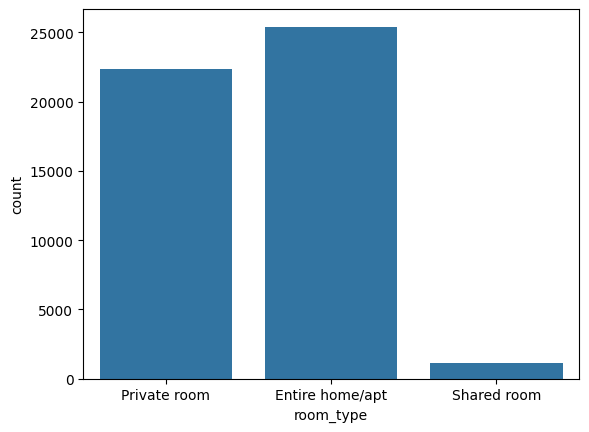

In [9]:
sns.countplot(x='room_type', data = df)

**Univariate Analysis**

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'host_id'}>,
        <Axes: title={'center': 'latitude'}>],
       [<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'minimum_nights'}>],
       [<Axes: title={'center': 'number_of_reviews'}>,
        <Axes: title={'center': 'reviews_per_month'}>,
        <Axes: title={'center': 'calculated_host_listings_count'}>],
       [<Axes: title={'center': 'availability_365'}>, <Axes: >, <Axes: >]],
      dtype=object)

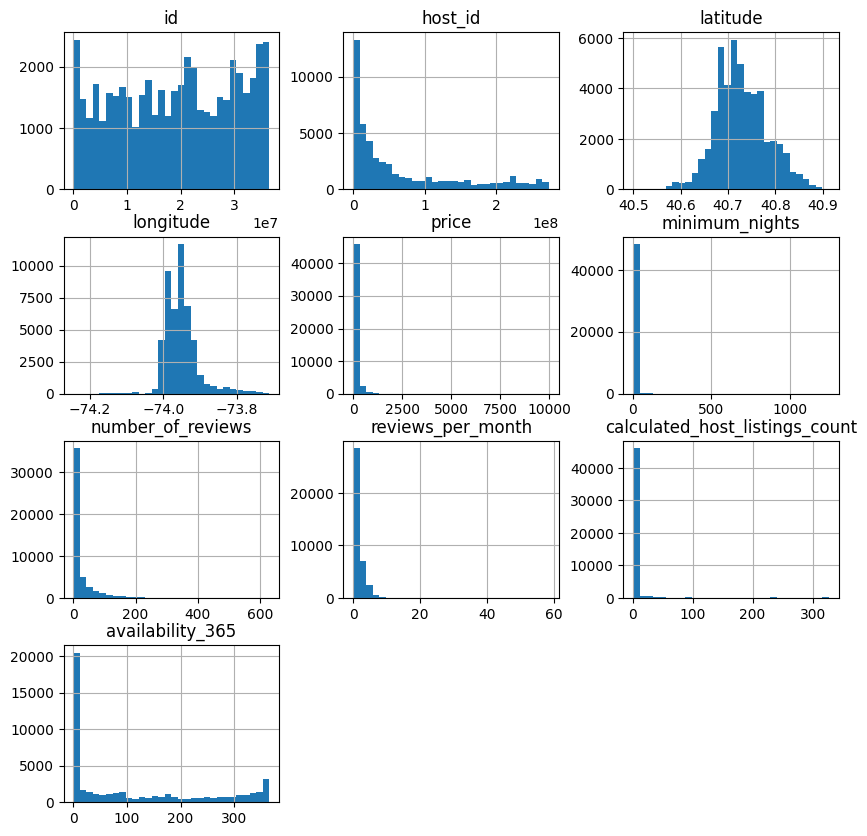

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols].hist(figsize=(10,10), bins=30)

<Axes: xlabel='neighbourhood_group', ylabel='count'>

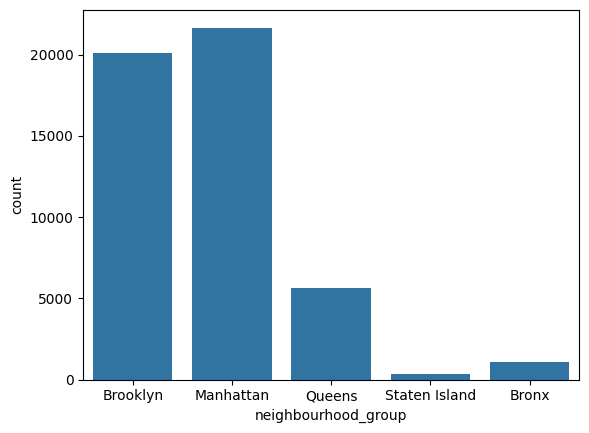

In [11]:
sns.countplot(data=df, x='neighbourhood_group')

**Bivariate Analysis**

<Axes: xlabel='room_type', ylabel='price'>

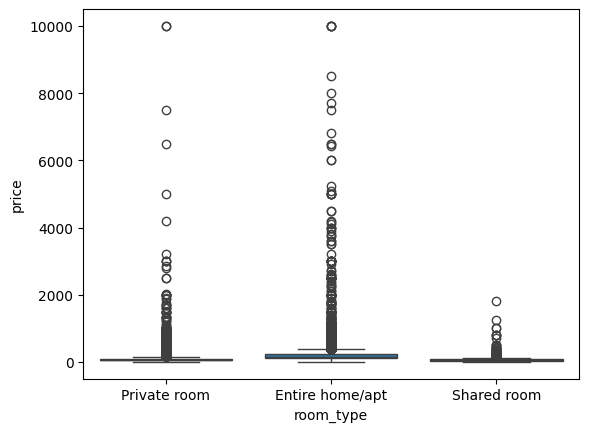

In [12]:
sns.boxplot(x='room_type', y = 'price', data=df)

**Corealation beetween numeric features**

<Axes: >

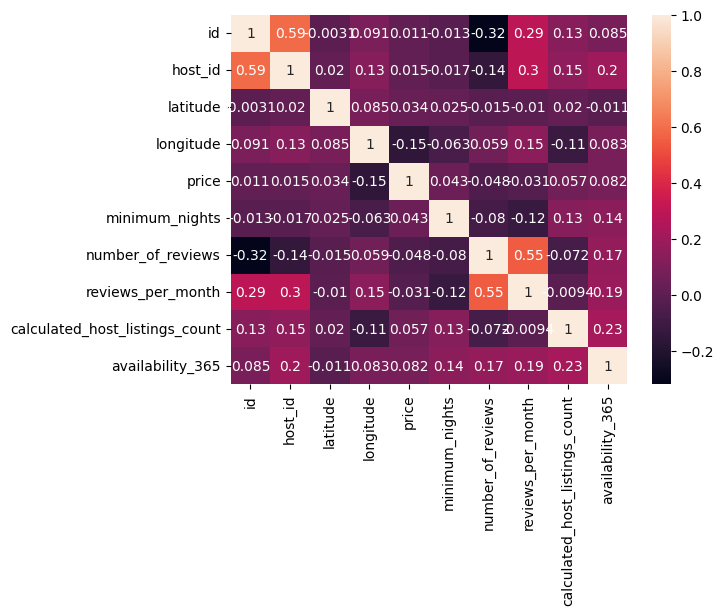

In [13]:
corr = df[numeric_cols].corr()
sns.heatmap(corr,annot=True)

<Axes: xlabel='longitude', ylabel='latitude'>

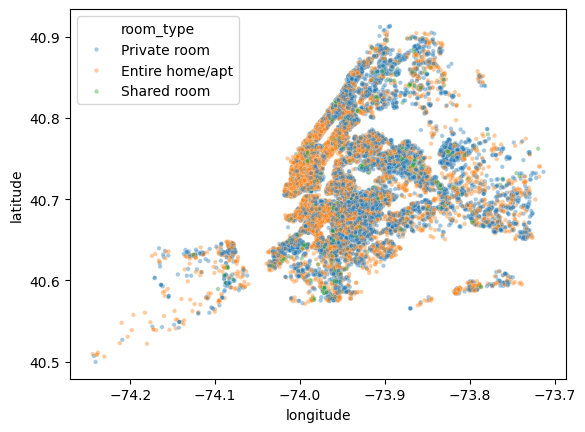

In [14]:
sns.scatterplot(x = 'longitude', y = 'latitude', data=df, hue='room_type', alpha= 0.4, s=10)

***DATA CLEANING PROCESS***

In [15]:
#1. drop col that does not help us 
df_clean = df.drop(columns=['id', 'host_name', 'host_id', 'name', 'last_review'])
df_clean

#2. No reviews yet -> 0 reviews permonth, not missing
df_clean['reviews_per_month'] = df_clean['reviews_per_month'].fillna(0)



In [16]:
#3. Cap extreme outlier instead of deleting rows and cols
price_cap = df_clean['price'].quantile(0.90)
night_cap = df_clean['minimum_nights'].quantile(0.90)

df_clean['price'] = df_clean['price'].clip(upper=price_cap)
df_clean['minimum_nights'] = df_clean['minimum_nights'].clip(upper=night_cap)



**Train test split**

In [17]:
X = df_clean.drop(columns=['room_type'])
y = df_clean['room_type']

***TRAIN TEST SPLIT***

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, stratify=y)

***PREPROCESSING***

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer

numeric_cols = [
    "latitude",
    "longitude",
    "price",
    "minimum_nights",
    "number_of_reviews",
    "reviews_per_month",
    "calculated_host_listings_count",
    "availability_365",
]
cat_cols = ["neighbourhood_group", "neighbourhood"]

# 1. Numeric col pipeline
numeric_pipeline = Pipeline(
    steps=[
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
)

# 2. Categorical col pipeline
cat_pipeline = Pipeline(
    steps=[
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("encode", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", cat_pipeline, cat_cols),
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

***TRYING MULTIPLE MODELS***

In [20]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_validate,cross_val_score

models = {
    "LogisticRegression": LogisticRegression(class_weight="balanced", random_state=42),
    "DecisionTreeClassifier": DecisionTreeClassifier(
        class_weight="balanced", random_state=42
    ),
    "RandomForestClassifier": RandomForestClassifier(
        # class_weight="balanced", random_state=42
    ),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    
    accuracy = cross_val_score(pipe,X_train,y_train,cv=3, scoring='accuracy')
    macro_f1 = cross_val_score(pipe,X_train,y_train,cv=3, scoring='f1_macro')
    print(f"{name} - Accuracy: {accuracy.mean():.4f}, Macro F1: {macro_f1.mean():.4f}")

In [23]:
from sklearn.model_selection import RandomizedSearchCV

best_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(class_weight="balanced", random_state=42)),
    ]
)

params_grid = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [100, 150],
    "model__min_samples_split": [2, 5],
}

search = RandomizedSearchCV(
    estimator=best_pipeline,
    param_distributions=params_grid,
    n_iter=10,
    cv=3,
    scoring="f1_macro",
    random_state=42,
)

search.fit(X_train, y_train)

print(f"Best_params_: {search.best_params_}")
print(f"Best_score_: {search.best_score_}")

Best_params_: {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__max_depth': 100}
Best_score_: 0.7275180780645476


Accuracy: 0.8573473770324164
F1 Score: 0.7551224216825818


<Axes: >

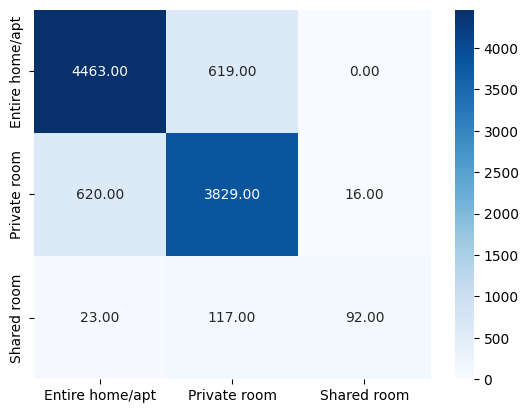

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
y_pred = search.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="macro"))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='.2f', cmap='Blues',xticklabels=search.classes_, yticklabels=search.classes_)

In [24]:
import joblib

joblib.dump(search.best_estimator_, "model_pipeline.pkl")
print("Model saved successfully!")

Model saved successfully!
